# omicsTL - Transfer Learning Example

<div>
<img src="images/tl_arch1.png" width="500" style="background-color: white;"/>
</div>

This notebook demonstrates a complete transfer-learning workflow using omicsTL. For clarity and reproducibility, we generate linked synthetic source and target datasets from two real viral proteomics datasets. This synthetic-data step is used here to showcase omicsTL’s simulation utilities and to create controlled source/target domain differences.

In practice, you can skip the simulation step and apply the same modeling workflow directly to real source and target datasets with minimal changes.

## Workflow summary

1. Load two real datasets (source and target).

2. Generate linked synthetic datasets with either a continuous or categorical response (for demonstration purposes only-not needed for real data application).

3. Split the synthetic target dataset into train, ensemble, and test partitions.

4. Package everything into a DatasetContainer.

5. Fit transfer learning models (deep learning and random forest variants).

6. Compare transfer learning vs target-only baselines.

# Imports and core utilities
We start by importing the simulation utilities needed to define a response function and generate synthetic data.

In [1]:
import warnings
warnings.filterwarnings("always")

from omicstl.simulation_utils.data_generation import response_function, generate_synth_data

# Load real datasets and define simulation settings
We use two real datasets with aligned features. The first represents the source domain used to train the base model; the second represents the target domain used for adaptation and evaluation.

We also define a non-trivial response function and choose sample sizes and the number of generated features.

In [2]:
import pandas as pd
import numpy as np

source_real_data_path = "data/source_data_real.csv"
target_real_data_path = "data/target_data_real.csv"

source_real_data = pd.read_csv(source_real_data_path, index_col=0)
target_real_data = pd.read_csv(target_real_data_path, index_col=0)

# Non-trivial continuous response function
response_fn = response_function("tanh(df[, 2]) + df[, 1] * df[, ncol(df)] ^ 2")

num_features = 100
num_samples_source = 100
num_samples_target = 50
samples_target_test = 25
samples_target_ensemble = 5

 # Generate linked synthetic datasets (continuous and categorical)

 We generate linked synthetic datasets for both a continuous and categorical response. The critical piece is passing *`prior_lc_info`* from the source simulation into the target simulation. This ensures the source and target synthetic datasets are coupled and reflect a coherent transfer-learning scenario

In [3]:
# Continuous response

source_synth_data_cont, source_lc_info_cont, _ = generate_synth_data(
    data = source_real_data, # input data
    num_features = num_features, # number of output features
    num_samples = num_samples_source, # number of output samples
    response_fn = response_fn, # response function
    snr = 1 # signal to noise ratio
)

target_synth_data_cont, _, _ = generate_synth_data(
    data = target_real_data, # input data
    num_features = num_features, # number of output features
    num_samples = num_samples_target + samples_target_test + samples_target_ensemble, # number of output samples
    response_fn = response_fn, # response function
    prior_lc_info = source_lc_info_cont, # crucial to include else the source and target datasets aren't linked!
    snr = 1 # signal to noise ratio
)

display(source_synth_data_cont)
display(target_synth_data_cont)

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,24.586326,4.425714,1.153352,0.692625,4.353530,0.913632,-1.651320,1.218818,1.004766,2.814767,...,8.390383,-1.334300,-1.922059,-1.492786,-2.521008,-2.893460,-0.362858,-1.291221,1.306347,2.310913
1,46.374888,4.269606,0.836482,1.288510,4.150999,1.755341,-1.756184,1.635103,1.017455,3.004204,...,8.263669,-0.944407,-1.971024,-1.467455,-2.352459,-3.195727,-0.623938,-1.055611,0.958582,3.295185
2,72.550371,4.550251,0.874845,1.567989,3.975012,1.022071,-1.606720,1.825202,0.895634,2.756546,...,8.265163,-2.375966,-2.182025,-1.022652,-2.150608,-2.994977,-0.523891,-1.640640,1.585385,4.279905
3,19.681603,4.120657,0.309883,0.576093,3.033254,1.552023,-2.113790,1.188120,0.655169,2.676087,...,8.658990,-1.608978,-1.739156,-0.946571,-2.555960,-2.833194,-0.483202,-1.319737,0.865443,2.368742
4,56.058978,4.400974,0.327041,1.103426,4.065841,1.743032,-1.564758,1.590581,0.712098,2.780759,...,7.951131,-0.106723,-2.443891,-1.258453,-2.698153,-3.120677,-0.325759,-1.226645,1.283420,2.773625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,53.426283,4.320571,0.944110,0.850386,4.157160,0.656147,-1.925578,1.219782,0.611743,2.736452,...,8.111243,-1.165180,-2.087097,-1.477542,-1.537007,-2.927464,-0.478513,-1.013706,0.874723,4.072679
96,45.648696,4.415451,0.697527,0.846747,4.073715,1.143263,-1.145713,1.926603,0.753992,2.781287,...,8.270089,-1.356076,-2.274928,-1.323934,-1.930981,-2.944699,-0.695070,-1.045855,1.332856,3.038580
97,36.668264,4.176085,0.692496,0.869408,3.874892,0.791601,-1.595045,0.943230,0.909757,2.772029,...,8.321999,-1.266429,-2.034215,-1.080296,-2.268519,-3.100882,-0.377638,-0.945456,1.091887,2.764401
98,56.252894,4.337403,0.310143,1.277737,4.038900,0.575372,-1.583093,1.432256,1.322947,2.682967,...,8.339321,-1.176913,-2.060003,-1.145424,-2.209228,-3.016570,-0.387370,-1.397636,1.208194,2.019372


,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,20.090187,4.565700,0.611720,1.667860,3.386795,1.414445,-1.375334,1.719566,0.781838,2.934225,...,8.142347,-1.664922,-2.588604,-0.668238,-1.772397,-3.071188,-1.008571,-1.373064,1.478066,2.698247
1,44.669774,4.139482,0.495328,0.869757,4.171264,1.139492,-1.903801,1.137553,1.287790,3.000881,...,8.404413,-1.615151,-2.340695,-1.511368,-1.782961,-3.055412,-0.393872,-1.488102,1.590556,3.699973
2,56.471552,4.626093,0.719510,1.764133,3.779621,1.250014,-1.389776,1.020151,0.848330,2.886758,...,8.299634,-1.022914,-1.456038,-0.712773,-2.125696,-2.808328,-0.693213,-1.136188,1.516913,3.333394
3,26.946179,4.444965,0.760644,1.062016,4.018549,1.142611,-2.375679,1.631228,0.935656,2.908972,...,8.113615,-1.197472,-1.765455,-1.631536,-2.449558,-2.823134,-0.625429,-1.242532,1.084352,2.369318
4,115.876684,4.144330,0.829555,0.880380,4.147575,0.940060,-2.229745,1.676652,1.074478,2.961513,...,8.055720,-1.025361,-1.619331,-1.372846,-2.219506,-3.078994,-0.544686,-1.005872,1.143274,4.276299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,79.921064,4.428683,0.718461,1.377986,4.342101,1.378215,-1.441867,1.765618,1.050711,2.851141,...,8.434747,-1.047560,-2.051117,-1.456667,-2.676387,-2.878485,-0.942755,-1.208091,0.976853,3.254722
76,20.726764,4.431824,0.607102,1.709205,4.029113,0.664080,-1.874231,0.872946,1.053032,2.719451,...,8.258087,-2.113942,-2.451248,-0.904588,-3.298451,-3.065282,-0.055125,-1.367091,1.251170,3.666689
77,47.852922,4.485981,0.909324,1.607470,4.066684,1.188615,-2.014278,1.713520,0.720498,2.879882,...,7.954165,-1.264980,-2.256257,-1.266125,-2.617437,-3.070382,-0.352373,-1.410830,1.600747,2.995853
78,36.437596,4.355784,0.447295,0.806992,4.208394,1.440416,-1.971406,1.665623,0.688287,2.717633,...,8.375831,-1.497076,-2.015062,-1.013277,-1.882182,-3.063640,-1.267704,-1.580220,1.041252,3.112907


In [4]:
# Categorical response
source_synth_data_cat, source_lc_info_cat, _ = generate_synth_data(
    data = source_real_data, # input data
    num_features = num_features, # number of output features
    num_samples = num_samples_source + samples_target_ensemble, # number of output samples
    response_fn = response_fn, # response function
    snr = 1, # signal to noise ratio
    response_parameters={
        "ncats": 3,
        "quantile": "quantile"
    }
)

target_synth_data_cat, source_lc_info_cat, _ = generate_synth_data(
    data = target_real_data, # input data
    num_features = num_features, # number of output features
    num_samples = num_samples_target + samples_target_test + samples_target_ensemble, # number of output samples
    response_fn = response_fn, # response function
    snr = 1 ,# signal to noise ratio
    prior_lc_info = source_lc_info_cat, # crucial to include else the source and target datasets aren't linked!
    response_parameters={
        "ncats": 3,
        "quantile": "quantile"
    }
)

display(source_synth_data_cat)
display(target_synth_data_cat)

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,3.0,1.179812,0.389538,1.571696,1.888265,8.586571,0.898698,-1.041631,3.286673,0.356131,...,1.251500,2.708139,-1.142844,3.048317,1.276481,3.329286,4.412827,5.921707,0.541401,4.985771
1,3.0,1.270117,-0.381090,1.088204,1.730044,8.653078,1.577223,0.018359,2.511734,1.497779,...,2.036967,2.586798,-1.008543,3.161339,1.091362,4.986467,4.580429,6.217200,0.674134,4.757731
2,3.0,1.034707,-0.405190,-1.491824,1.530693,8.507151,1.057465,-0.801320,3.604296,1.544322,...,1.638247,2.769530,-1.277835,3.303082,1.738137,3.705635,4.752068,5.643290,-0.007181,5.038790
3,1.0,0.665188,-0.276939,-0.499759,1.780362,8.379044,1.570308,-0.770939,4.283611,1.244347,...,1.546557,2.702046,-1.249569,3.218801,1.823524,3.435449,5.697707,6.562386,-0.127183,4.681617
4,2.0,1.006021,-0.016324,0.082787,1.694164,8.286303,1.015748,-0.826494,1.696752,1.233017,...,1.758458,2.571432,-1.335952,3.472472,1.184087,3.776768,4.874759,7.822732,0.702095,4.616842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,3.0,1.275197,-0.254878,1.197454,1.799326,8.030148,0.905338,-0.097485,4.168999,1.497779,...,1.381751,2.837457,-1.195763,3.273886,1.252096,3.086680,5.827777,7.025749,0.910354,5.041037
101,2.0,0.973711,0.148239,0.358231,1.359772,7.940306,1.328439,-1.097579,2.696672,1.533392,...,1.811179,2.847174,-1.244355,3.009831,0.790544,3.748787,5.191378,6.316280,0.649005,4.951799
102,1.0,0.681464,-0.282061,1.154942,1.691814,8.203929,1.011971,-0.411417,4.257420,0.488246,...,1.707684,2.966922,-1.060023,3.421124,1.531515,2.804252,3.379565,8.761067,0.559195,4.686744
103,2.0,1.029349,-0.385984,0.523205,1.628976,8.449021,1.437019,-0.819037,3.957947,1.566044,...,1.636944,2.806371,-1.150147,2.816664,1.303791,3.901251,4.205592,7.064180,0.222026,4.593109


,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,1.0,0.646728,-0.314152,0.989596,1.490442,8.148284,1.181995,-0.250656,3.241516,1.334670,...,1.397999,2.980513,-1.127505,2.844888,1.642341,3.600337,4.459957,5.143304,0.630059,5.112434
1,2.0,1.028563,-0.430035,0.987251,1.619800,8.406672,1.600593,-0.092721,3.232331,1.511374,...,1.671344,2.595719,-1.383649,2.927238,1.194438,3.738586,4.852317,7.970343,0.308322,4.779348
2,1.0,0.930608,-0.493147,1.193101,1.400958,8.508456,1.044884,-0.125215,2.311549,1.016826,...,2.046383,2.580454,-1.186388,3.461495,1.782418,3.785453,4.797501,6.793874,0.888833,4.637849
3,3.0,1.044779,0.040320,-0.937600,1.492898,8.431025,0.783053,-0.218774,3.645703,1.376317,...,1.690292,2.604248,-1.402134,3.375746,1.482383,3.040787,4.610438,8.115360,0.226322,4.724445
4,1.0,0.787586,-0.388155,0.219846,1.382525,8.147639,1.582048,-0.130373,3.905539,1.239293,...,1.874455,2.648344,-1.361762,3.158290,1.005414,3.660837,4.368857,7.436066,0.466830,4.555460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,1.0,0.811001,-0.387138,2.003418,1.579904,8.371929,1.032700,-0.683811,1.934983,0.999229,...,1.812047,2.838498,-1.314390,3.368375,1.109137,3.855523,4.780619,7.211215,0.217943,5.020561
76,3.0,1.168241,-0.031144,1.063129,1.791884,8.316357,1.325951,-1.305908,3.722625,1.086772,...,1.766824,2.832176,-1.331309,3.380409,1.251426,4.940774,4.643942,5.914257,0.562557,4.903312
77,2.0,0.795563,-0.172521,0.594835,1.658000,8.773182,0.791710,-0.531292,2.432798,1.713761,...,1.351920,2.874169,-1.169052,3.579971,1.546948,4.692203,4.520488,7.167762,0.210704,5.003173
78,1.0,0.695203,-0.446111,0.316414,1.288065,7.990620,1.094259,-0.328120,1.790622,1.250995,...,1.596829,2.689037,-1.002362,2.961477,1.546184,4.668764,4.813619,9.006885,0.539050,4.989994


# Standardize response column naming
We rename the response column to "response" for consistency across model fitting, and we cast the categorical response to integer labels

In [5]:
# Set response column name

source_synth_data_cont.rename(columns={source_synth_data_cont.columns[0]: 'response'}, inplace=True)
target_synth_data_cont.rename(columns={target_synth_data_cont.columns[0]: 'response'}, inplace=True)
display(source_synth_data_cont)
display(target_synth_data_cont)

source_synth_data_cat.rename(columns={source_synth_data_cat.columns[0]: 'response'}, inplace=True)
target_synth_data_cat.rename(columns={target_synth_data_cat.columns[0]: 'response'}, inplace=True)
source_synth_data_cat = source_synth_data_cat.astype({"response": np.int64})
target_synth_data_cat = target_synth_data_cat.astype({"response": np.int64})
display(source_synth_data_cat)
display(target_synth_data_cat)

,response,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,24.586326,4.425714,1.153352,0.692625,4.353530,0.913632,-1.651320,1.218818,1.004766,2.814767,...,8.390383,-1.334300,-1.922059,-1.492786,-2.521008,-2.893460,-0.362858,-1.291221,1.306347,2.310913
1,46.374888,4.269606,0.836482,1.288510,4.150999,1.755341,-1.756184,1.635103,1.017455,3.004204,...,8.263669,-0.944407,-1.971024,-1.467455,-2.352459,-3.195727,-0.623938,-1.055611,0.958582,3.295185
2,72.550371,4.550251,0.874845,1.567989,3.975012,1.022071,-1.606720,1.825202,0.895634,2.756546,...,8.265163,-2.375966,-2.182025,-1.022652,-2.150608,-2.994977,-0.523891,-1.640640,1.585385,4.279905
3,19.681603,4.120657,0.309883,0.576093,3.033254,1.552023,-2.113790,1.188120,0.655169,2.676087,...,8.658990,-1.608978,-1.739156,-0.946571,-2.555960,-2.833194,-0.483202,-1.319737,0.865443,2.368742
4,56.058978,4.400974,0.327041,1.103426,4.065841,1.743032,-1.564758,1.590581,0.712098,2.780759,...,7.951131,-0.106723,-2.443891,-1.258453,-2.698153,-3.120677,-0.325759,-1.226645,1.283420,2.773625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,53.426283,4.320571,0.944110,0.850386,4.157160,0.656147,-1.925578,1.219782,0.611743,2.736452,...,8.111243,-1.165180,-2.087097,-1.477542,-1.537007,-2.927464,-0.478513,-1.013706,0.874723,4.072679
96,45.648696,4.415451,0.697527,0.846747,4.073715,1.143263,-1.145713,1.926603,0.753992,2.781287,...,8.270089,-1.356076,-2.274928,-1.323934,-1.930981,-2.944699,-0.695070,-1.045855,1.332856,3.038580
97,36.668264,4.176085,0.692496,0.869408,3.874892,0.791601,-1.595045,0.943230,0.909757,2.772029,...,8.321999,-1.266429,-2.034215,-1.080296,-2.268519,-3.100882,-0.377638,-0.945456,1.091887,2.764401
98,56.252894,4.337403,0.310143,1.277737,4.038900,0.575372,-1.583093,1.432256,1.322947,2.682967,...,8.339321,-1.176913,-2.060003,-1.145424,-2.209228,-3.016570,-0.387370,-1.397636,1.208194,2.019372


,response,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,20.090187,4.565700,0.611720,1.667860,3.386795,1.414445,-1.375334,1.719566,0.781838,2.934225,...,8.142347,-1.664922,-2.588604,-0.668238,-1.772397,-3.071188,-1.008571,-1.373064,1.478066,2.698247
1,44.669774,4.139482,0.495328,0.869757,4.171264,1.139492,-1.903801,1.137553,1.287790,3.000881,...,8.404413,-1.615151,-2.340695,-1.511368,-1.782961,-3.055412,-0.393872,-1.488102,1.590556,3.699973
2,56.471552,4.626093,0.719510,1.764133,3.779621,1.250014,-1.389776,1.020151,0.848330,2.886758,...,8.299634,-1.022914,-1.456038,-0.712773,-2.125696,-2.808328,-0.693213,-1.136188,1.516913,3.333394
3,26.946179,4.444965,0.760644,1.062016,4.018549,1.142611,-2.375679,1.631228,0.935656,2.908972,...,8.113615,-1.197472,-1.765455,-1.631536,-2.449558,-2.823134,-0.625429,-1.242532,1.084352,2.369318
4,115.876684,4.144330,0.829555,0.880380,4.147575,0.940060,-2.229745,1.676652,1.074478,2.961513,...,8.055720,-1.025361,-1.619331,-1.372846,-2.219506,-3.078994,-0.544686,-1.005872,1.143274,4.276299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,79.921064,4.428683,0.718461,1.377986,4.342101,1.378215,-1.441867,1.765618,1.050711,2.851141,...,8.434747,-1.047560,-2.051117,-1.456667,-2.676387,-2.878485,-0.942755,-1.208091,0.976853,3.254722
76,20.726764,4.431824,0.607102,1.709205,4.029113,0.664080,-1.874231,0.872946,1.053032,2.719451,...,8.258087,-2.113942,-2.451248,-0.904588,-3.298451,-3.065282,-0.055125,-1.367091,1.251170,3.666689
77,47.852922,4.485981,0.909324,1.607470,4.066684,1.188615,-2.014278,1.713520,0.720498,2.879882,...,7.954165,-1.264980,-2.256257,-1.266125,-2.617437,-3.070382,-0.352373,-1.410830,1.600747,2.995853
78,36.437596,4.355784,0.447295,0.806992,4.208394,1.440416,-1.971406,1.665623,0.688287,2.717633,...,8.375831,-1.497076,-2.015062,-1.013277,-1.882182,-3.063640,-1.267704,-1.580220,1.041252,3.112907


,response,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,3,1.179812,0.389538,1.571696,1.888265,8.586571,0.898698,-1.041631,3.286673,0.356131,...,1.251500,2.708139,-1.142844,3.048317,1.276481,3.329286,4.412827,5.921707,0.541401,4.985771
1,3,1.270117,-0.381090,1.088204,1.730044,8.653078,1.577223,0.018359,2.511734,1.497779,...,2.036967,2.586798,-1.008543,3.161339,1.091362,4.986467,4.580429,6.217200,0.674134,4.757731
2,3,1.034707,-0.405190,-1.491824,1.530693,8.507151,1.057465,-0.801320,3.604296,1.544322,...,1.638247,2.769530,-1.277835,3.303082,1.738137,3.705635,4.752068,5.643290,-0.007181,5.038790
3,1,0.665188,-0.276939,-0.499759,1.780362,8.379044,1.570308,-0.770939,4.283611,1.244347,...,1.546557,2.702046,-1.249569,3.218801,1.823524,3.435449,5.697707,6.562386,-0.127183,4.681617
4,2,1.006021,-0.016324,0.082787,1.694164,8.286303,1.015748,-0.826494,1.696752,1.233017,...,1.758458,2.571432,-1.335952,3.472472,1.184087,3.776768,4.874759,7.822732,0.702095,4.616842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,3,1.275197,-0.254878,1.197454,1.799326,8.030148,0.905338,-0.097485,4.168999,1.497779,...,1.381751,2.837457,-1.195763,3.273886,1.252096,3.086680,5.827777,7.025749,0.910354,5.041037
101,2,0.973711,0.148239,0.358231,1.359772,7.940306,1.328439,-1.097579,2.696672,1.533392,...,1.811179,2.847174,-1.244355,3.009831,0.790544,3.748787,5.191378,6.316280,0.649005,4.951799
102,1,0.681464,-0.282061,1.154942,1.691814,8.203929,1.011971,-0.411417,4.257420,0.488246,...,1.707684,2.966922,-1.060023,3.421124,1.531515,2.804252,3.379565,8.761067,0.559195,4.686744
103,2,1.029349,-0.385984,0.523205,1.628976,8.449021,1.437019,-0.819037,3.957947,1.566044,...,1.636944,2.806371,-1.150147,2.816664,1.303791,3.901251,4.205592,7.064180,0.222026,4.593109


,response,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,1,0.646728,-0.314152,0.989596,1.490442,8.148284,1.181995,-0.250656,3.241516,1.334670,...,1.397999,2.980513,-1.127505,2.844888,1.642341,3.600337,4.459957,5.143304,0.630059,5.112434
1,2,1.028563,-0.430035,0.987251,1.619800,8.406672,1.600593,-0.092721,3.232331,1.511374,...,1.671344,2.595719,-1.383649,2.927238,1.194438,3.738586,4.852317,7.970343,0.308322,4.779348
2,1,0.930608,-0.493147,1.193101,1.400958,8.508456,1.044884,-0.125215,2.311549,1.016826,...,2.046383,2.580454,-1.186388,3.461495,1.782418,3.785453,4.797501,6.793874,0.888833,4.637849
3,3,1.044779,0.040320,-0.937600,1.492898,8.431025,0.783053,-0.218774,3.645703,1.376317,...,1.690292,2.604248,-1.402134,3.375746,1.482383,3.040787,4.610438,8.115360,0.226322,4.724445
4,1,0.787586,-0.388155,0.219846,1.382525,8.147639,1.582048,-0.130373,3.905539,1.239293,...,1.874455,2.648344,-1.361762,3.158290,1.005414,3.660837,4.368857,7.436066,0.466830,4.555460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,1,0.811001,-0.387138,2.003418,1.579904,8.371929,1.032700,-0.683811,1.934983,0.999229,...,1.812047,2.838498,-1.314390,3.368375,1.109137,3.855523,4.780619,7.211215,0.217943,5.020561
76,3,1.168241,-0.031144,1.063129,1.791884,8.316357,1.325951,-1.305908,3.722625,1.086772,...,1.766824,2.832176,-1.331309,3.380409,1.251426,4.940774,4.643942,5.914257,0.562557,4.903312
77,2,0.795563,-0.172521,0.594835,1.658000,8.773182,0.791710,-0.531292,2.432798,1.713761,...,1.351920,2.874169,-1.169052,3.579971,1.546948,4.692203,4.520488,7.167762,0.210704,5.003173
78,1,0.695203,-0.446111,0.316414,1.288065,7.990620,1.094259,-0.328120,1.790622,1.250995,...,1.596829,2.689037,-1.002362,2.961477,1.546184,4.668764,4.813619,9.006885,0.539050,4.989994


# Split target into train, ensemble, and test

* We split the target dataset into:

* train: used for target-side fitting/adaptation

* ensemble: a small held-out target partition used to estimate performance-based weights for combining individual random forest models into a weighted ensemble

* test: final evaluation set

For categorical responses, we stratify splits to ensure each partition contains all classes.

In [6]:
from sklearn.model_selection import train_test_split

target_synth_train_comb_cont, target_synth_test_cont = train_test_split(
    target_synth_data_cont,
    train_size = num_samples_target + samples_target_ensemble,
    test_size = samples_target_test
)

target_synth_train_comb_cat, target_synth_test_cat = train_test_split(
    target_synth_data_cat,
    train_size = num_samples_target + samples_target_ensemble,
    test_size = samples_target_test,
    stratify = target_synth_data_cat['response'] # crucial or else random forest might break due to partition not representing all classes.
)

target_synth_train_cont, target_synth_train_ensemble_cont = train_test_split(
    target_synth_train_comb_cont,
    train_size = num_samples_target,
    test_size = samples_target_ensemble
)

target_synth_train_cat, target_synth_train_ensemble_cat = train_test_split(
    target_synth_train_comb_cat,
    train_size = num_samples_target,
    test_size = samples_target_ensemble,
    stratify = target_synth_train_comb_cat['response'] # crucial or else random forest might break due to partition not representing all classes.
)

# Create DatasetContainer objects
We provide a DatasetContainer helper class to keep the different datasets organized. Optionally, `id_tuple` can also be set which is used to label the scenario and replicate IDs if performing large scale simulation studies. These IDs are passed to the output after model fitting.

In [7]:
from omicstl.simulation_utils.data_utils import DatasetContainer
datasets_cont = DatasetContainer(
	source_data=source_synth_data_cont,
	target_data=target_synth_train_cont,
    target_ensemble_data=target_synth_train_ensemble_cont,
	target_test_data=[target_synth_test_cont]
)
datasets_cont.set_response_column("response") # Identify response column

datasets_cat = DatasetContainer(
	source_data=source_synth_data_cat,
	target_data=target_synth_train_cat,
    target_ensemble_data=target_synth_train_ensemble_cat,
	target_test_data=[target_synth_test_cat]
)
datasets_cat.set_response_column("response") # Identify response column

# Fit transfer-learning models (deep learning and random forest)

We demonstrate both deep learning and random-forest transfer learning models. Deep learning models support automatic tuning over a parameter grid via *fit_dl_model*. Random forest models are fit through a Python interface to the R implementation

In [8]:
param_grid = {
	"dropout": [0.25, 0.5],
	"n_latent_dims": [2],
	"hidden_dim_base": [6],
	"lr": [0.01, 0.001],
	"source_epochs": [1000],
	"target_epochs": [1000],
	"freeze": ["none"],
	"weight_decay": [1e-4, 1e-2],
	"gamma": [1, 2, 3]
}

Deep learning models can be fit using a DatasetContainer and parameter grid using `fit_dl_model`, which returns a dataframe with results, the trained transfer learning model, and the model trained on only the target dataset.

In [9]:
import torch
from torch import device
import random
from omicstl.simulation_utils.model_utils import fit_dl_model

random.seed(42)
torch.manual_seed(42)
out, mult_vae_cont_model, model_targetonly = fit_dl_model(
	datasets_cont,
	"mult_vae",
	device("cpu"),
	param_grid
)
display(out)

random.seed(42)
torch.manual_seed(42)
out, mult_vae_cat_model, model_targetonly = fit_dl_model(
	datasets_cat,
	"mult_vae",
	device("cpu"),
	param_grid
)
display(out)

/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1057: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1057: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)


,scenario,replicate,split,model,model_type,model_id,rmse,mae,acc,f1,...,dropout,hidden_dim_base,n_latent_dims,source_epochs,target_epochs,freeze,z_dim_base,lr,weight_decay,gamma
0,None,None,test_0,mult_vae,mult_vae,target,26.127803,22.506361,NaN,NaN,...,0.25,6.0,2.0,1000.0,1000.0,none,12.0,0.01,0.01,3.0
1,None,None,test_0,mult_vae,mult_vae,target_nosource,23.957784,19.931203,NaN,NaN,...,0.25,6.0,2.0,1000.0,1000.0,none,12.0,0.01,0.01,1.0


/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1057: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1057: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1057: FutureWarning: The behavior of DataFrame concatenation with empt

,scenario,replicate,split,model,model_type,model_id,rmse,mae,acc,f1,...,dropout,hidden_dim_base,n_latent_dims,source_epochs,target_epochs,freeze,z_dim_base,lr,weight_decay,gamma
0,None,None,test_0,mult_vae,mult_vae,target,NaN,NaN,0.32,0.155152,...,0.25,6.0,2.0,1000.0,1000.0,none,12.0,0.01,0.0001,1.0
1,None,None,test_0,mult_vae,mult_vae,target_nosource,NaN,NaN,0.32,0.155152,...,0.25,6.0,2.0,1000.0,1000.0,none,12.0,0.01,0.0100,3.0


In [10]:
random.seed(42)
torch.manual_seed(42)
out, mult_mlp_cont_model, model_targetonly = fit_dl_model(
	datasets_cont,
	"mult_mlp",
	device("cpu"),
	param_grid
)
display(out)

random.seed(42)
torch.manual_seed(42)
out, mult_mlp_cat_model, model_targetonly = fit_dl_model(
	datasets_cat,
	"mult_mlp",
	device("cpu"),
	param_grid
)
display(out)

/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1057: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1057: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)


,scenario,replicate,split,model,model_type,model_id,rmse,mae,acc,f1,...,dropout,hidden_dim_base,n_latent_dims,source_epochs,target_epochs,freeze,z_dim_base,lr,weight_decay,gamma
0,None,None,test_0,mult_mlp,mult_mlp,target,26.772371,22.038831,NaN,NaN,...,0.25,6.0,2.0,1000.0,1000.0,none,12.0,0.01,0.0001,3.0
1,None,None,test_0,mult_mlp,mult_mlp,target_nosource,25.045333,21.609379,NaN,NaN,...,0.25,6.0,2.0,1000.0,1000.0,none,12.0,0.01,0.0001,1.0


/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1057: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1057: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1057: FutureWarning: The behavior of DataFrame concatenation with empt

,scenario,replicate,split,model,model_type,model_id,rmse,mae,acc,f1,...,dropout,hidden_dim_base,n_latent_dims,source_epochs,target_epochs,freeze,z_dim_base,lr,weight_decay,gamma
0,None,None,test_0,mult_mlp,mult_mlp,target,NaN,NaN,0.24,0.236000,...,0.5,6.0,2.0,1000.0,1000.0,none,12.0,0.010,0.01,3.0
1,None,None,test_0,mult_mlp,mult_mlp,target_nosource,NaN,NaN,0.28,0.144516,...,0.5,6.0,2.0,1000.0,1000.0,none,12.0,0.001,0.01,3.0


The random forest based models can also be fit using a python interface to the R modeling code.

In [11]:
from omicstl.r_utils import set_seed
from omicstl.simulation_utils.model_utils import fit_rf_model

random.seed(42)
out, rf_cont_model = fit_rf_model(datasets_cont)
display(out)

random.seed(42)
set_seed(42)
out, rf_cat_model = fit_rf_model(datasets_cat)
display(out)

/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1258: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([test_row])], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1258: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([test_row])], ignore_index=True)


,scenario,replicate,split,model,model_type,model_id,rmse,mae,acc,f1,mcc,precision,recall,roc_auc
0,None,None,test_0,rf,pred_source_full,target,18.973092,16.149499,NaN,NaN,NaN,NaN,NaN,NaN
1,None,None,test_0,rf,pred_source_full_val,target,18.973092,16.149499,NaN,NaN,NaN,NaN,NaN,NaN
2,None,None,test_0,rf,pred_0_full,target,20.569750,16.147142,NaN,NaN,NaN,NaN,NaN,NaN
3,None,None,test_0,rf,pred_0_full_val,target,20.569750,16.147142,NaN,NaN,NaN,NaN,NaN,NaN
4,None,None,test_0,rf,pred_1_full,target,18.684550,14.266620,NaN,NaN,NaN,NaN,NaN,NaN
5,None,None,test_0,rf,pred_1_full_val,target,18.684550,14.266620,NaN,NaN,NaN,NaN,NaN,NaN
6,None,None,test_0,rf,pred_2_full,target,19.858573,17.169485,NaN,NaN,NaN,NaN,NaN,NaN
7,None,None,test_0,rf,pred_2_full_val,target,19.858573,17.169485,NaN,NaN,NaN,NaN,NaN,NaN
8,None,None,test_0,rf,pred_3_full,target,20.598272,16.035206,NaN,NaN,NaN,NaN,NaN,NaN
9,None,None,test_0,rf,pred_3_full_val,target,20.598272,16.035206,NaN,NaN,NaN,NaN,NaN,NaN


/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1258: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([test_row])], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1258: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([test_row])], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1258: FutureWarning: The behavior of DataFrame

,scenario,replicate,split,model,model_type,model_id,rmse,mae,acc,f1,mcc,precision,recall,roc_auc
0,None,None,test_0,rf,pred_source_full,target,NaN,NaN,0.48,0.454072,0.269953,0.571765,0.48,0.709118
1,None,None,test_0,rf,pred_source_full_val,target,NaN,NaN,0.56,0.532492,0.414732,0.702588,0.56,0.709118
2,None,None,test_0,rf,pred_0_full,target,NaN,NaN,0.52,0.489351,0.306698,0.517333,0.52,0.647941
3,None,None,test_0,rf,pred_0_full_val,target,NaN,NaN,0.24,0.228421,-0.134367,0.265455,0.24,0.647941
4,None,None,test_0,rf,pred_1_full,target,NaN,NaN,0.60,0.593810,0.413549,0.622000,0.60,0.764853
5,None,None,test_0,rf,pred_1_full_val,target,NaN,NaN,0.44,0.396842,0.182537,0.410909,0.44,0.764853
6,None,None,test_0,rf,pred_2_full,target,NaN,NaN,0.40,0.336533,0.142058,0.583193,0.40,0.686912
7,None,None,test_0,rf,pred_2_full_val,target,NaN,NaN,0.44,0.380237,0.196430,0.449333,0.44,0.686912
8,None,None,test_0,rf,pred_3_full,target,NaN,NaN,0.36,0.315263,0.053966,0.318571,0.36,0.667353
9,None,None,test_0,rf,pred_3_full_val,target,NaN,NaN,0.48,0.466238,0.240247,0.509143,0.48,0.667353


# Predicting data using a pretrained transfer learning model

Once you have created a model, you can then use it to predict response values for novel inputs.
For deep learning models you can use the `predict_dl_model` function.

In [12]:
from omicstl.simulation_utils.model_utils import predict_dl_model

# Create "new" data by shuffling existing values
new_synth_data_cont = source_synth_data_cont.iloc[:, 1:]
values = new_synth_data_cont.values.flatten()
np.random.shuffle(values)
new_synth_data_cont = pd.DataFrame(
    values.reshape(new_synth_data_cont.shape),
    columns=new_synth_data_cont.columns
)

new_synth_data_cat = source_synth_data_cat.iloc[:, 1:]
values = new_synth_data_cat.values.flatten()
np.random.shuffle(values)
new_synth_data_cat = pd.DataFrame(
    values.reshape(new_synth_data_cat.shape),
    columns=new_synth_data_cat.columns
)

# Get predicted response values on the new data
out = predict_dl_model(mult_vae_cont_model, new_synth_data_cont)
display(out)

out = predict_dl_model(mult_vae_cat_model, new_synth_data_cat)
display(out)

out = predict_dl_model(mult_mlp_cont_model, new_synth_data_cont)
display(out)

out = predict_dl_model(mult_mlp_cat_model, new_synth_data_cat)
display(out)

array([-0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 ,
       -0.57643193, -0.5764265 , -0.57672435, -0.5764265 , -0.5764265 ,
       -0.5764265 , -0.5764265 , -0.5764384 , -0.5769194 , -0.5764265 ,
       -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 ,
       -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 ,
       -0.5764265 , -0.5764265 , -0.57727206, -0.5764265 , -0.5764265 ,
       -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 ,
       -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 , -0.57674116,
       -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 ,
       -0.5764265 , -0.5764265 , -0.5768697 , -0.5764265 , -0.5764265 ,
       -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 ,
       -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 ,
       -0.5764265 , -0.576745  , -0.5764265 , -0.5764265 , -0.5764265 ,
       -0.5764265 , -0.5764265 , -0.5764265 , -0.5764265 , -0.57

array([0, 0, 2, 1, 0, 0, 0, 2, 2, 2, 0, 2, 0, 1, 2, 0, 0, 0, 0, 0, 2, 2,
       2, 2, 0, 0, 0, 0, 1, 2, 2, 0, 0, 2, 0, 0, 0, 1, 2, 2, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 1, 2, 0,
       0, 2, 2, 0, 0, 2, 2, 0, 0, 0, 0, 2, 1, 0, 1, 1, 0, 0, 0, 0, 0, 2,
       0, 2, 2, 2, 0, 2, 0, 2, 0, 0, 0, 1, 2, 0, 0, 0, 0])

array([ 0.06644619, -0.58158374, -0.7944905 , -0.81579244, -0.20831084,
       -0.53928244, -0.53928244, -0.32285425, -0.8077244 , -0.675892  ,
       -1.1519823 , -0.53928244, -0.53928244, -1.1509486 , -0.79140866,
       -0.6264805 , -0.53928244, -0.57809246, -1.1073813 , -0.70898914,
       -0.53928244, -0.54641104, -0.7469665 , -0.63122225, -0.53928244,
       -0.43682688, -0.6760045 , -0.86454546, -0.5705031 , -0.53928244,
       -0.53928244, -0.6688167 , -1.1553181 , -0.53928244, -0.53928244,
       -0.59058815, -0.5460683 , -0.56798285, -0.85594445, -0.8797529 ,
       -0.53928244, -0.53928244, -0.39882678, -0.7395464 , -0.52461934,
       -0.8052929 , -0.61493826, -0.76812387, -0.6341763 , -0.9663818 ,
       -0.53928244, -0.74550706, -0.9750607 , -0.90994954, -1.2659993 ,
       -0.5438712 , -0.25637245,  0.13677347, -0.53928244, -0.53928244,
       -1.0862975 , -0.7405455 , -0.36894763, -0.5632805 , -0.87425536,
        0.17468762, -0.2326464 , -0.33631048, -0.7393203 , -0.53

array([1, 0, 2, 1, 0, 1, 2, 2, 2, 2, 1, 1, 2, 1, 2, 0, 1, 1, 0, 0, 2, 2,
       2, 2, 1, 2, 1, 2, 1, 1, 2, 0, 2, 2, 0, 0, 2, 0, 2, 2, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 2, 1, 2, 2, 0, 1, 2, 1, 0, 0, 2, 2, 2,
       1, 1, 2, 0, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 0, 0, 0, 1, 2, 0, 1, 0,
       1, 2, 1, 2, 1, 1, 0, 2, 0, 0, 2, 2, 2, 0, 0, 0, 0])

Similarly, you can use the `predict_rf_model` function to predict response values using a random forest model. Random forest predictions will include the predicted responses of each of the transfer learning methods. You can select the appropriate method by observing the reported accuracies of each method from the original `fit_rf_model` call.

In [13]:
from omicstl.simulation_utils.model_utils import predict_rf_model

out = predict_rf_model(rf_cont_model, new_synth_data_cont)
display(pd.DataFrame(out))

out = predict_rf_model(rf_cat_model, new_synth_data_cat)
display(pd.DataFrame(out))

,pred_source,pred_0,pred_1,pred_2,pred_3,pred_ensemble
0,-0.389291,-0.498726,-0.467986,-0.333564,-0.501810,-0.454568
1,-0.418861,-0.525067,-0.502672,-0.432885,-0.511280,-0.494796
2,-0.801302,-0.644595,-0.701344,-0.760651,-0.650530,-0.685989
3,-0.463276,-0.602346,-0.538611,-0.478562,-0.572233,-0.550674
4,-0.358231,-0.520035,-0.463036,-0.369973,-0.508212,-0.469081
...,...,...,...,...,...,...
95,-0.398077,-0.552682,-0.516736,-0.405848,-0.544064,-0.508208
96,-0.408225,-0.537890,-0.505638,-0.388576,-0.517180,-0.490242
97,-0.364084,-0.540685,-0.492209,-0.333445,-0.524160,-0.477188
98,-0.391208,-0.537666,-0.490648,-0.361453,-0.517879,-0.480710


,pred_source,pred_source_prob_1,pred_source_prob_2,pred_source_prob_3,pred_0,pred_0_prob_1,pred_0_prob_2,pred_0_prob_3,pred_1,pred_1_prob_1,...,pred_2_prob_2,pred_2_prob_3,pred_3,pred_3_prob_1,pred_3_prob_2,pred_3_prob_3,pred_ensemble,pred_ensemble_prob_1,pred_ensemble_prob_2,pred_ensemble_prob_3
0,1,0.520,0.442,0.038,1,0.348,0.368,0.284,2,0.416,...,0.447861,0.075467,2,0.380,0.394,0.226,2,0.348673,0.423739,0.227588
1,1,0.484,0.474,0.042,1,0.296,0.370,0.334,2,0.406,...,0.539974,0.019165,2,0.360,0.412,0.228,1,0.337402,0.462532,0.200066
2,1,0.550,0.414,0.036,1,0.340,0.326,0.334,1,0.476,...,0.425072,0.021161,1,0.386,0.380,0.234,2,0.391504,0.407663,0.200833
3,2,0.452,0.488,0.060,1,0.374,0.350,0.276,1,0.506,...,0.522461,0.060157,1,0.386,0.414,0.200,1,0.377120,0.406479,0.216401
4,2,0.166,0.434,0.400,1,0.320,0.326,0.354,2,0.374,...,0.440488,0.354451,3,0.328,0.330,0.342,3,0.270150,0.308828,0.421023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,1,0.538,0.414,0.048,2,0.312,0.350,0.338,1,0.390,...,0.411594,0.083408,2,0.334,0.440,0.226,2,0.326892,0.426903,0.246205
101,1,0.554,0.402,0.044,1,0.324,0.360,0.316,1,0.418,...,0.391693,0.130168,1,0.352,0.416,0.232,1,0.333285,0.403814,0.262900
102,1,0.538,0.434,0.028,1,0.386,0.362,0.252,1,0.472,...,0.448441,0.057592,2,0.390,0.414,0.196,2,0.380326,0.405923,0.213751
103,1,0.488,0.482,0.030,1,0.402,0.332,0.266,1,0.416,...,0.509332,0.007199,1,0.436,0.370,0.194,1,0.396000,0.439577,0.164423


# Shapley Values

Users can get Shapley values using the built-in `get_shapley_values_dl` and `get_shapley_values_rf` functions.

In [14]:
from omicstl.shapley import get_shapley_values_dl

source_input_cont = datasets_cont.source_data
target_input_cont = datasets_cont.target_test_data[0]

shap_dl_mlp_cont = get_shapley_values_dl(
    source_input=source_input_cont,
    target_input=target_input_cont,
    pretrained_model=mult_mlp_cont_model,
    background_sample_size=20,
    shap_sample_size=50,
    response_id="response"
)
display(shap_dl_mlp_cont)

shap_dl_vae_cont = get_shapley_values_dl(
    source_input=source_input_cont,
    target_input=target_input_cont,
    pretrained_model=mult_vae_cont_model,
    background_sample_size=20,
    shap_sample_size=50,
    response_id="response"
)
display(shap_dl_vae_cont)

source_input_cat = datasets_cat.source_data
target_input_cat = datasets_cat.target_test_data[0]

shap_dl_cont = get_shapley_values_dl(
    source_input=source_input_cat,
    target_input=target_input_cat,
    pretrained_model=mult_mlp_cat_model,
    background_sample_size=20,
    shap_sample_size=50,
    response_id="response"
)
display(shap_dl_mlp_cont)

shap_dl_cont = get_shapley_values_dl(
    source_input=source_input_cat,
    target_input=target_input_cat,
    pretrained_model=mult_vae_cat_model,
    background_sample_size=20,
    shap_sample_size=50,
    response_id="response"
)
display(shap_dl_vae_cont)


  0%|          | 0/25 [00:00<?, ?it/s]

/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=4.908e-03, with an active set of 5 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=2.424e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=2.424e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 5.96

{1:         1         2         3         4    5         6         7         8    \
 74  0.00000  0.000000  0.017205  0.000000  0.0  0.000000  0.000000  0.016256   
 6   0.00000  0.000000  0.000000  0.000000  0.0 -0.000639  0.000000  0.000000   
 22  0.00000  0.000000  0.000000  0.000000  0.0  0.006054  0.000000  0.000000   
 72  0.00000  0.000000  0.000000 -0.006483  0.0  0.000000  0.000000  0.000000   
 56  0.00000  0.000000  0.000000  0.000000  0.0  0.000000  0.000000  0.004147   
 61  0.00237  0.000000  0.000000  0.000000  0.0 -0.003892  0.000000  0.000000   
 39  0.00000  0.009944  0.000000  0.000000  0.0  0.000000  0.000000  0.000000   
 67  0.00000  0.000000  0.000000  0.000000  0.0  0.000000  0.000000  0.000000   
 30  0.00000  0.000000  0.000000  0.000000  0.0  0.000000  0.000000  0.000000   
 35  0.00000  0.000000  0.000000  0.000000  0.0  0.000000  0.000000  0.000000   
 65  0.00000  0.000000  0.000000  0.000000  0.0  0.000000  0.000000  0.000000   
 15  0.00000  0.000000 -0

  0%|          | 0/25 [00:00<?, ?it/s]

{1:     1    2    3    4    5    6    7    8    9    10   ...  91   92   93   94   \
 74  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 6   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 22  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 72  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 56  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 61  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 39  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 67  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 30  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 35  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 65  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 15  0.0  0.0

...

/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=9.089e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=9.089e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=8.064e-03, with an active set of 9 regressors, and the smallest cholesky pivot element being 5.96

{1:         1         2         3         4    5         6         7         8    \
 74  0.00000  0.000000  0.017205  0.000000  0.0  0.000000  0.000000  0.016256   
 6   0.00000  0.000000  0.000000  0.000000  0.0 -0.000639  0.000000  0.000000   
 22  0.00000  0.000000  0.000000  0.000000  0.0  0.006054  0.000000  0.000000   
 72  0.00000  0.000000  0.000000 -0.006483  0.0  0.000000  0.000000  0.000000   
 56  0.00000  0.000000  0.000000  0.000000  0.0  0.000000  0.000000  0.004147   
 61  0.00237  0.000000  0.000000  0.000000  0.0 -0.003892  0.000000  0.000000   
 39  0.00000  0.009944  0.000000  0.000000  0.0  0.000000  0.000000  0.000000   
 67  0.00000  0.000000  0.000000  0.000000  0.0  0.000000  0.000000  0.000000   
 30  0.00000  0.000000  0.000000  0.000000  0.0  0.000000  0.000000  0.000000   
 35  0.00000  0.000000  0.000000  0.000000  0.0  0.000000  0.000000  0.000000   
 65  0.00000  0.000000  0.000000  0.000000  0.0  0.000000  0.000000  0.000000   
 15  0.00000  0.000000 -0

  0%|          | 0/25 [00:00<?, ?it/s]

/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=8.275e-03, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=3.878e-03, with an active set of 1 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=2.615e-03, with an active set of 4 regressors, and the smallest cholesky pivot element being 5.96

{1:     1    2    3    4    5    6    7    8    9    10   ...  91   92   93   94   \
 74  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 6   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 22  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 72  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 56  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 61  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 39  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 67  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 30  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 35  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 65  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 15  0.0  0.0

In [ ]:
from omicstl.shapley import get_shapley_values_rf

shap_rf_cont = get_shapley_values_rf(
    source_input=source_input_cont,
    target_input=target_input_cont,
    pretrained_model=rf_cont_model,
    background_sample_size=20,
    shap_sample_size=50,
    response_id="response"
)
display(shap_dl_cont)

shap_rf_cat = get_shapley_values_rf(
    source_input=source_input_cat,
    target_input=target_input_cat,
    pretrained_model=rf_cat_model,
    background_sample_size=20,
    shap_sample_size=50,
    response_id="response"
)
display(shap_rf_cat)

  0%|          | 0/25 [00:00<?, ?it/s]

/opt/venv/lib/python3.12/site-packages/shap/explainers/_kernel.py:765: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=3.308e-03, with an active set of 1 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 i

{1:          1         2         3         4    5    6         7         8    \
 38  0.000000  0.000000  0.002253  0.000000  0.0  0.0  0.000000  0.000000   
 14  0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.000000  0.000000   
 71  0.000000  0.000000  0.000000 -0.005154  0.0  0.0  0.000000  0.000000   
 58  0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.000000 -0.075318   
 31  0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.000000  0.000000   
 16  0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.000000  0.000000   
 10  0.000000  0.000000 -0.007602  0.000000  0.0  0.0  0.000000  0.000000   
 47  0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.000000 -0.011277   
 70  0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.000000  0.000000   
 6   0.000000  0.000000  0.000000  0.027770  0.0  0.0  0.000000  0.000000   
 42  0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.000000  0.000000   
 75  0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.000000  0.000000

  0%|          | 0/25 [00:00<?, ?it/s]

/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=2.823e-03, with an active set of 5 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=2.347e-03, with an active set of 7 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=2.347e-03, with an active set of 7 regressors, and the smallest cholesky pivot element being 5.96

{1:     1         2    3         4         5         6         7         8    \
 38  0.0  0.000000  0.0  0.000000  0.000000  0.000593  0.000000  0.000000   
 14  0.0  0.000000  0.0  0.000000  0.000000  0.000000  0.000000  0.000000   
 71  0.0  0.000000  0.0  0.000000  0.000000  0.000000  0.000000  0.000000   
 58  0.0  0.006750  0.0  0.000000  0.000000  0.000000  0.000000  0.000000   
 31  0.0  0.000000  0.0  0.000000  0.000000  0.000000  0.000000  0.000000   
 16  0.0  0.000000  0.0  0.000000  0.000000 -0.031521  0.000000  0.000000   
 10  0.0  0.000000  0.0  0.000000  0.000000  0.000000  0.000000  0.000000   
 47  0.0  0.000000  0.0  0.000000  0.000000  0.000000  0.000000  0.000000   
 70  0.0  0.000000  0.0  0.000000  0.000000  0.000000  0.000000  0.000000   
 6   0.0  0.000000  0.0 -0.010262  0.000000  0.000000  0.000000  0.000000   
 42  0.0  0.139864  0.0 -0.008212  0.000000  0.000000  0.000000  0.000000   
 75  0.0  0.000000  0.0  0.000000  0.051923  0.000000  0.000000  0.000000

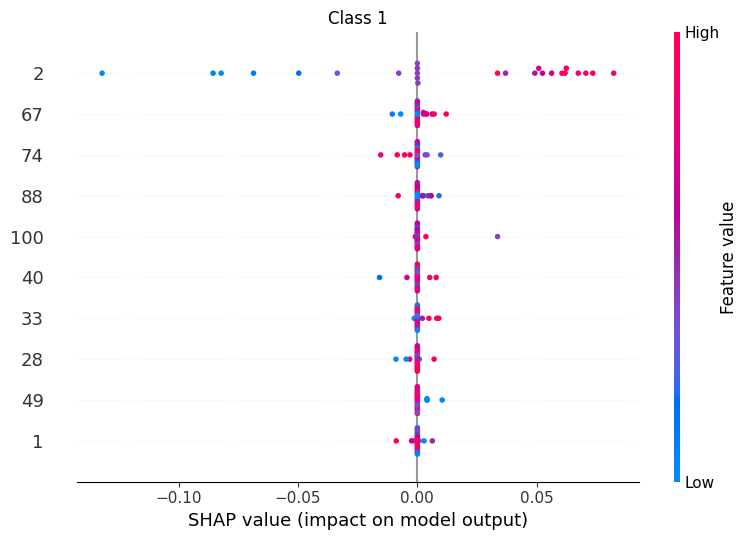

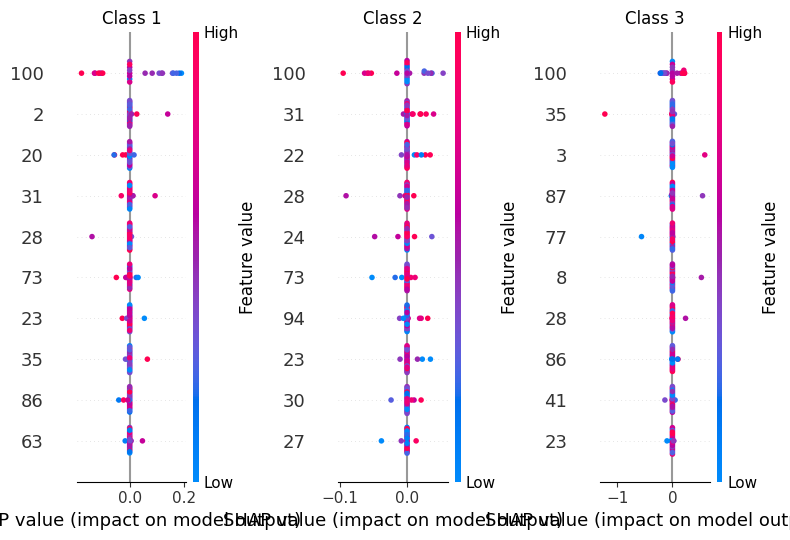

In [ ]:
import importlib
import omicstl.shapley
importlib.reload(omicstl.shapley)
from omicstl.shapley import plot_shapley_values

plot_shapley_values(shap_rf_cont)

# Categorical plots require a class map.
plot_shapley_values(shap_rf_cat, class_map = {1: "Class 1", 2: "Class 2", 3: "Class 3"})

# Advanced usage
Advanced users can also work directly with the base classes we provide for each TL model via TransferForest() and MultiViewModel(). 